# 03 - Held-out transfer and feature RSA

Notebook 02 identified a **pilot lead** in `subj01`: Set B natural-image geometry appeared similar across vision and imagery, but its reliability was inconsistent. This notebook asks whether that lead replicates in held-out subjects 02-08 and whether HOG or CLIP better explains any transferable geometry.

The analysis is intentionally staged:

1. Establish neural reliability and vision-imagery transfer across subjects and ROIs.
2. Only then interpret the geometry using low-level HOG and higher-level CLIP features.

Set A is the controlled low-level comparison. Set C remains exploratory and is excluded because it lacks one fixed visual exemplar per concept.

## 0. Update the environment once

Notebook 03 adds `scikit-image`, PyTorch, and Transformers. From a terminal in the repository, run:

```bash
conda env update -n nsdimagery -f environment.yml
```

Then restart Jupyter and explicitly select **Kernel -> Change Kernel -> Python (NSD-Imagery)**. A terminal environment and a notebook kernel are separate processes: activating conda in the terminal does not change an already-running notebook. The first cell below prints `sys.executable`; it should point inside the `nsdimagery` environment. The environment pins Python 3.12 as a conservative, reproducible common denominator across PyTorch, Transformers, and conda-forge packages. CLIP runs on CPU for only 12 images, so no GPU is required.

In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'nsdimagery').is_dir():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / 'nsdimagery').is_dir():
    raise RuntimeError('Start Jupyter from the repository root or its notebooks/ directory.')
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import skimage
from IPython.display import display
from PIL import Image
from skimage.color import rgb2gray
from skimage.feature import hog
from skimage.transform import resize

from nsdimagery import (
    balanced_split_reliability, build_event_table, correlation_rdm, cosine_rdm,
    exact_label_permutation_test, exact_sign_flip_test,
    extract_masked_betas, find_data_root, independent_group_reliability,
    load_roi, load_target_table, paths_for_subject, rdm_spearman,
    target_rdm, zscore_within_groups,
)

sns.set_theme(style='whitegrid', context='notebook')
DATA_ROOT = find_data_root(REPO_ROOT)
print('Python:', sys.version.split()[0])
print('Python executable:', sys.executable)
print('scikit-image:', skimage.__version__)
print('Repository:', REPO_ROOT)
print('Data root:', DATA_ROOT)

Python: 3.12.13
Python executable: /srv/conda/envs/nsdimagery/bin/python
scikit-image: 0.26.0
Repository: /home/jovyan/NHprojectNSDimagery
Data root: /home/jovyan/NHprojectNSDimagery/data/nsd


## 1. Analysis contract

`subj01` is displayed as the pilot but excluded from confirmatory group tests. Subjects 02-08 are held out. The pre-specified neural test is positive Set B vision-imagery RDM correlation in higher visual cortex. The higher-minus-early contrast is secondary.

ROI definitions:

| Analysis ROI | Released mask | Labels |
|---|---|---|
| `nsdgeneral` | `nsdgeneral` | all positive voxels |
| `early_visual` | `prf-visualrois` | 1-6: V1-V3 dorsal/ventral |
| `higher_visual` | `streams` | 5-7: ventral, lateral, parietal |

We report all subjects; reliability is an interpretation aid, never a post-hoc exclusion rule.

In [2]:
SUBJECTS = tuple(range(1, 9))
PILOT_SUBJECT = 1
STIMULUS_SETS = ('A', 'B')
ROI_SPECS = {
    'nsdgeneral': {'mask_name': 'nsdgeneral', 'labels': None},
    'early_visual': {'mask_name': 'prf-visualrois', 'labels': tuple(range(1, 7))},
    'higher_visual': {'mask_name': 'streams', 'labels': (5, 6, 7)},
}
ROI_ORDER = list(ROI_SPECS)
MAX_VOXELS_PER_ROI = 1200
N_VISION_SPLITS = 200
BASE_SEED = 2026
RUN_CLIP = True
CLIP_MODEL_NAME = 'openai/clip-vit-base-patch32'

OUTPUT_DIR = REPO_ROOT / 'outputs' / '03_group_transfer_feature_rsa'
CACHE_DIR = DATA_ROOT / 'derived' / 'notebook03_beta_cache'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print('Subjects:', SUBJECTS)
print('Pilot:', PILOT_SUBJECT, '| held out:', [s for s in SUBJECTS if s != PILOT_SUBJECT])
print('Voxel cap per subject/ROI:', MAX_VOXELS_PER_ROI)
print('Beta cache:', CACHE_DIR)

Subjects: (1, 2, 3, 4, 5, 6, 7, 8)
Pilot: 1 | held out: [2, 3, 4, 5, 6, 7, 8]
Voxel cap per subject/ROI: 1200
Beta cache: /home/jovyan/NHprojectNSDimagery/data/nsd/derived/notebook03_beta_cache


The first complete run reads at most 1,200 voxels for each subject and ROI. Each extraction is cached under the data directory. Subsequent runs reuse those arrays, so statistical and plotting cells become fast. Changing the voxel cap or seed creates a distinct cache file.

In [3]:
def cache_path(subject, roi_name, seed):
    voxel_token = 'all' if MAX_VOXELS_PER_ROI is None else str(MAX_VOXELS_PER_ROI)
    return CACHE_DIR / f'subj{subject:02d}_{roi_name}_n{voxel_token}_seed{seed}.npz'

def load_or_extract_roi_betas(subject, roi_name, roi_index):
    spec = ROI_SPECS[roi_name]
    seed = BASE_SEED + subject * 100 + roi_index
    path = cache_path(subject, roi_name, seed)
    if path.is_file():
        with np.load(path) as cached:
            betas = cached['betas']
            coordinates = cached['coordinates']
        print(f'  {roi_name}: cache hit, {betas.shape[1]} voxels')
        return betas, coordinates

    mask, _ = load_roi(DATA_ROOT, subject, spec['mask_name'])
    betas, coordinates = extract_masked_betas(
        paths_for_subject(DATA_ROOT, subject)['beta'],
        mask, labels=spec['labels'], max_voxels=MAX_VOXELS_PER_ROI, seed=seed,
    )
    np.savez_compressed(path, betas=betas, coordinates=coordinates)
    print(f'  {roi_name}: extracted and cached {betas.shape[1]} voxels')
    return betas, coordinates

## 2. Build neural RDMs across all subjects

For each subject and ROI we:

1. select the 432 vision/imagery beta patterns;
2. standardize each voxel within its run;
3. average target repetitions;
4. compare vision and imagery RDMs;
5. estimate vision reliability using 200 balanced random half-splits;
6. estimate imagery reliability by comparing the two independent imagery runs.

This is the longest cell on its first run. Progress is printed by subject and ROI.

In [4]:
neural_rows = []
neural_rdms = {}

for subject in SUBJECTS:
    print(f'\nsubj{subject:02d}')
    events = build_event_table(DATA_ROOT, subject).reset_index(drop=True)
    for roi_index, roi_name in enumerate(ROI_ORDER):
        all_betas, coordinates = load_or_extract_roi_betas(subject, roi_name, roi_index)
        trial_patterns = all_betas[events['beta_index'].to_numpy()]
        normalized = zscore_within_groups(trial_patterns, events['run_name'].to_numpy())

        for set_index, stimulus_set in enumerate(STIMULUS_SETS):
            task_rdms = {}
            for task in ('vision', 'imagery'):
                frame = events[
                    events['stimulus_set'].eq(stimulus_set) & events['task'].eq(task)
                ]
                positions = frame.index.to_numpy()
                rdm, target_order = target_rdm(
                    normalized[positions], frame['target_number'].to_numpy()
                )
                assert np.array_equal(target_order, np.arange(1, 7))
                task_rdms[task] = rdm
                neural_rdms[(subject, roi_name, stimulus_set, task)] = rdm

            transfer_test = exact_label_permutation_test(
                task_rdms['vision'], task_rdms['imagery']
            )
            vision_frame = events[
                events['stimulus_set'].eq(stimulus_set) & events['task'].eq('vision')
            ]
            vision_positions = vision_frame.index.to_numpy()
            split_rhos = balanced_split_reliability(
                normalized[vision_positions],
                vision_frame['target_number'].to_numpy(),
                n_splits=N_VISION_SPLITS,
                seed=BASE_SEED + subject * 1000 + roi_index * 10 + set_index,
            )
            imagery_frame = events[
                events['stimulus_set'].eq(stimulus_set) & events['task'].eq('imagery')
            ]
            imagery_positions = imagery_frame.index.to_numpy()
            imagery_reliability = independent_group_reliability(
                normalized[imagery_positions],
                imagery_frame['target_number'].to_numpy(),
                imagery_frame['run_name'].to_numpy(),
            )
            neural_rows.append({
                'subject': subject,
                'phase': 'pilot' if subject == PILOT_SUBJECT else 'heldout',
                'roi': roi_name,
                'stimulus_set': stimulus_set,
                'n_voxels': len(coordinates),
                'vision_split_rho_median': float(np.median(split_rhos)),
                'vision_split_rho_q25': float(np.quantile(split_rhos, .25)),
                'vision_split_rho_q75': float(np.quantile(split_rhos, .75)),
                'imagery_run_rho': imagery_reliability,
                'vision_imagery_rho': transfer_test['observed'],
                'transfer_p_greater': transfer_test['p_greater'],
                'transfer_p_two_sided': transfer_test['p_two_sided'],
            })

neural_metrics = pd.DataFrame(neural_rows)
print('\nMetric rows:', len(neural_metrics))
display(neural_metrics.head(12))
assert len(neural_metrics) == len(SUBJECTS) * len(ROI_SPECS) * len(STIMULUS_SETS)


subj01
  nsdgeneral: cache hit, 1200 voxels
  early_visual: cache hit, 1200 voxels
  higher_visual: cache hit, 1200 voxels

subj02
  nsdgeneral: cache hit, 1200 voxels
  early_visual: cache hit, 1200 voxels
  higher_visual: cache hit, 1200 voxels

subj03
  nsdgeneral: cache hit, 1200 voxels
  early_visual: cache hit, 1200 voxels
  higher_visual: cache hit, 1200 voxels

subj04
  nsdgeneral: cache hit, 1200 voxels
  early_visual: cache hit, 1200 voxels
  higher_visual: cache hit, 1200 voxels

subj05
  nsdgeneral: cache hit, 1200 voxels
  early_visual: cache hit, 1200 voxels
  higher_visual: cache hit, 1200 voxels

subj06
  nsdgeneral: cache hit, 1200 voxels
  early_visual: cache hit, 1200 voxels
  higher_visual: cache hit, 1200 voxels

subj07
  nsdgeneral: cache hit, 1200 voxels
  early_visual: cache hit, 1200 voxels
  higher_visual: cache hit, 1200 voxels

subj08
  nsdgeneral: cache hit, 1200 voxels
  early_visual: cache hit, 1200 voxels
  higher_visual: cache hit, 1200 voxels

Metric 

,subject,phase,roi,stimulus_set,n_voxels,vision_split_rho_median,vision_split_rho_q25,vision_split_rho_q75,imagery_run_rho,vision_imagery_rho,transfer_p_greater,transfer_p_two_sided
0,1,pilot,nsdgeneral,A,1200,0.067857,-0.065179,0.239286,0.153571,0.214286,0.280556,0.545833
1,1,pilot,nsdgeneral,B,1200,0.175000,0.000000,0.339286,-0.303571,0.646429,0.018056,0.033333
2,1,pilot,early_visual,A,1200,0.407143,0.291071,0.533036,0.171429,-0.153571,0.681944,0.665278
3,1,pilot,early_visual,B,1200,-0.010714,-0.187500,0.171429,-0.410714,0.214286,0.255556,0.519444
4,1,pilot,higher_visual,A,1200,0.041071,-0.154464,0.194643,-0.010714,0.367857,0.130556,0.247222
5,1,pilot,higher_visual,B,1200,0.126786,-0.061607,0.337500,-0.307143,0.439286,0.079167,0.173611
6,2,heldout,nsdgeneral,A,1200,0.367857,0.250000,0.514286,0.292857,0.371429,0.119444,0.243056
7,2,heldout,nsdgeneral,B,1200,0.150000,0.027679,0.275893,0.114286,0.846429,0.002778,0.002778
8,2,heldout,early_visual,A,1200,0.541071,0.458036,0.640179,0.060714,0.117857,0.348611,0.730556
9,2,heldout,early_visual,B,1200,0.267857,0.131250,0.408929,-0.303571,0.614286,0.026389,0.050000


## 3. Held-out neural-transfer test

The exact six-label permutation tests in the previous table describe each subject. Generalization is assessed here with exact sign flips across subjects 02-08. With seven held-out subjects there are only $2^7=128$ possible sign patterns, so the attainable p-values are discrete.

In [5]:
heldout_neural = neural_metrics[neural_metrics['phase'].eq('heldout')].copy()
group_rows = []
for (stimulus_set, roi_name), frame in heldout_neural.groupby(['stimulus_set', 'roi']):
    values = frame['vision_imagery_rho'].to_numpy()
    test = exact_sign_flip_test(values)
    group_rows.append({
        'stimulus_set': stimulus_set,
        'roi': roi_name,
        'n_subjects': len(values),
        'mean_rho': values.mean(),
        'median_rho': np.median(values),
        'p_greater': test['p_greater'],
        'p_two_sided': test['p_two_sided'],
    })
neural_group_summary = pd.DataFrame(group_rows).sort_values(['stimulus_set', 'roi'])
display(neural_group_summary)

set_b_wide = (
    heldout_neural[heldout_neural['stimulus_set'].eq('B')]
    .pivot(index='subject', columns='roi', values='vision_imagery_rho')
)
higher_minus_early = (set_b_wide['higher_visual'] - set_b_wide['early_visual']).to_numpy()
primary_values = set_b_wide['higher_visual'].to_numpy()
primary_test = exact_sign_flip_test(primary_values)
roi_contrast_test = exact_sign_flip_test(higher_minus_early)
confirmatory_tests = pd.DataFrame([
    {
        'test': 'Set B higher-visual transfer > 0 (primary)',
        'mean_effect': primary_values.mean(),
        'p_greater': primary_test['p_greater'],
        'p_two_sided': primary_test['p_two_sided'],
    },
    {
        'test': 'Set B higher minus early transfer > 0 (secondary)',
        'mean_effect': higher_minus_early.mean(),
        'p_greater': roi_contrast_test['p_greater'],
        'p_two_sided': roi_contrast_test['p_two_sided'],
    },
])
display(confirmatory_tests)

,stimulus_set,roi,n_subjects,mean_rho,median_rho,p_greater,p_two_sided
0,A,early_visual,7,0.415306,0.342857,0.007812,0.015625
1,A,higher_visual,7,0.269388,0.250000,0.093750,0.187500
2,A,nsdgeneral,7,0.339286,0.328571,0.015625,0.031250
3,B,early_visual,7,0.134694,-0.067857,0.234375,0.468750
4,B,higher_visual,7,0.365306,0.314286,0.007812,0.015625
5,B,nsdgeneral,7,0.364286,0.360714,0.031250,0.062500


,test,mean_effect,p_greater,p_two_sided
0,Set B higher-visual transfer > 0 (primary),0.365306,0.007812,0.015625
1,Set B higher minus early transfer > 0 (secondary),0.230612,0.164062,0.328125


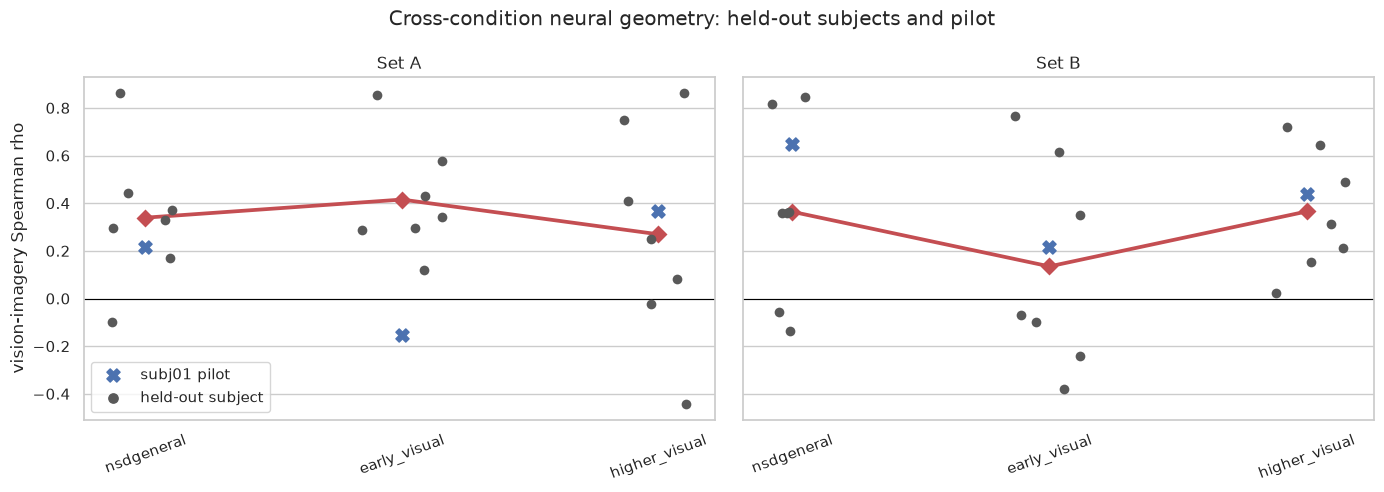

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, stimulus_set in zip(axes, STIMULUS_SETS):
    heldout = heldout_neural[heldout_neural['stimulus_set'].eq(stimulus_set)]
    pilot = neural_metrics[
        neural_metrics['stimulus_set'].eq(stimulus_set)
        & neural_metrics['phase'].eq('pilot')
    ]
    sns.stripplot(
        data=heldout, x='roi', y='vision_imagery_rho', order=ROI_ORDER,
        color='0.35', jitter=.16, size=7, ax=ax,
    )
    sns.pointplot(
        data=heldout, x='roi', y='vision_imagery_rho', order=ROI_ORDER,
        color='#c44e52', errorbar=None, markers='D', linestyles='-', ax=ax,
    )
    for x, roi_name in enumerate(ROI_ORDER):
        value = pilot.loc[pilot['roi'].eq(roi_name), 'vision_imagery_rho'].iloc[0]
        ax.scatter(x, value, marker='X', s=90, color='#4c72b0', zorder=5)
    ax.axhline(0, color='black', linewidth=.8)
    ax.set(title=f'Set {stimulus_set}', xlabel='', ylabel='vision-imagery Spearman rho')
    ax.tick_params(axis='x', rotation=20)
axes[0].scatter([], [], marker='X', s=90, color='#4c72b0', label='subj01 pilot')
axes[0].scatter([], [], marker='o', s=45, color='0.35', label='held-out subject')
axes[0].legend(loc='lower left')
fig.suptitle('Cross-condition neural geometry: held-out subjects and pilot')
plt.tight_layout()

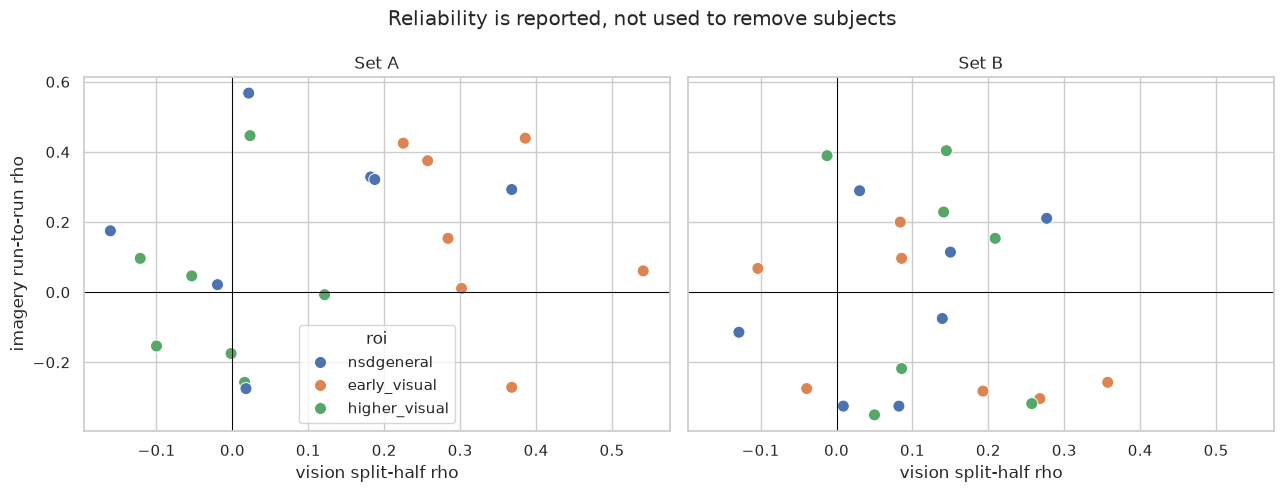

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for ax, stimulus_set in zip(axes, STIMULUS_SETS):
    frame = heldout_neural[heldout_neural['stimulus_set'].eq(stimulus_set)]
    sns.scatterplot(
        data=frame, x='vision_split_rho_median', y='imagery_run_rho',
        hue='roi', hue_order=ROI_ORDER, s=75, ax=ax,
    )
    ax.axhline(0, color='black', linewidth=.7)
    ax.axvline(0, color='black', linewidth=.7)
    ax.set(title=f'Set {stimulus_set}', xlabel='vision split-half rho', ylabel='imagery run-to-run rho')
axes[1].get_legend().remove()
fig.suptitle('Reliability is reported, not used to remove subjects')
plt.tight_layout()

### Neural decision point

The primary evidence is the held-out Set B higher-visual distribution and its sign-flip test, not the pilot marker. Positive transfer with reasonable run-to-run imagery reliability supports feature interpretation. A weak or heterogeneous result is still informative: it means the apparent `subj01` transfer is not a stable population effect in this small dataset. Do not tune ROIs or remove subjects in response to this table.

## 4. Build HOG and CLIP feature RDMs

HOG encodes local edge orientation and spatial layout. CLIP image embeddings provide a higher-level visual-semantic representation. Both are computed from the same 12 fixed target images in sets A and B. Feature RDMs use cosine distance, the native comparison for normalized CLIP embeddings; RSA compares RDM ranks, not raw distance scales.

In [8]:
targets = (
    load_target_table(DATA_ROOT)
    .query('stimulus_set in @STIMULUS_SETS')
    .sort_values(['stimulus_set', 'target_number'])
    .reset_index(drop=True)
)
assert targets['image_path'].notna().all()
assert targets.groupby('stimulus_set').size().eq(6).all()
display(targets[['stimulus_set', 'target_number', 'target_code', 'target_name']])

def extract_hog(paths):
    vectors = []
    for path in paths:
        with Image.open(path) as image:
            rgb = np.asarray(image.convert('RGB'), dtype=np.float32) / 255
        gray = rgb2gray(resize(rgb, (224, 224), anti_aliasing=True))
        vectors.append(hog(
            gray, orientations=9, pixels_per_cell=(16, 16),
            cells_per_block=(2, 2), block_norm='L2-Hys', feature_vector=True,
        ))
    return np.stack(vectors)

feature_vectors = {}
for stimulus_set, frame in targets.groupby('stimulus_set', sort=True):
    feature_vectors[(stimulus_set, 'HOG')] = extract_hog(frame['image_path'].tolist())
    print(f'Set {stimulus_set} HOG:', feature_vectors[(stimulus_set, 'HOG')].shape)

,stimulus_set,target_number,target_code,target_name
0,A,1,H,bar_000.0deg_450L_43W.png
1,A,2,R,bar_045.0deg_450L_43W.png
2,A,3,V,bar_090.0deg_450L_43W.png
3,A,4,L,bar_135.0deg_450L_43W.png
4,A,5,P,crs_000.0deg_450L_43W.png
5,A,6,E,crs_045.0deg_450L_43W.png
6,B,1,W,shared0385_nsd28752.png
7,B,2,K,shared0413_nsd30857.png
8,B,3,B,shared0741_nsd53882.png
9,B,4,C,shared0842_nsd61178.png


Set A HOG: (6, 6084)
Set B HOG: (6, 6084)


In [9]:
clip_error = None
if RUN_CLIP:
    try:
        import torch
        import transformers
        from transformers import AutoProcessor, CLIPVisionModelWithProjection

        print('PyTorch:', torch.__version__)
        print('Transformers:', transformers.__version__)
        print('Loading:', CLIP_MODEL_NAME)
        processor = AutoProcessor.from_pretrained(CLIP_MODEL_NAME)
        model = CLIPVisionModelWithProjection.from_pretrained(CLIP_MODEL_NAME).eval()
        clip_vectors = {}
        for stimulus_set, frame in targets.groupby('stimulus_set', sort=True):
            images = []
            for path in frame['image_path']:
                with Image.open(path) as image:
                    images.append(image.convert('RGB').copy())
            inputs = processor(images=images, return_tensors='pt')
            with torch.inference_mode():
                vectors = model(pixel_values=inputs['pixel_values']).image_embeds
                vectors = vectors / vectors.norm(dim=1, keepdim=True)
            clip_vectors[(stimulus_set, 'CLIP')] = vectors.cpu().numpy()
            print(f'Set {stimulus_set} CLIP:', vectors.shape)
        feature_vectors.update(clip_vectors)
        del model
    except Exception as error:
        clip_error = error
        feature_vectors = {key: value for key, value in feature_vectors.items() if key[1] != 'CLIP'}
        print('CLIP unavailable; neural transfer and HOG RSA can still finish.')
        print(type(error).__name__ + ':', error)
        if isinstance(error, ModuleNotFoundError):
            print('This kernel is missing a CLIP dependency.')
            print('Current Python:', sys.executable)
            print('Select the Python (NSD-Imagery) kernel, then restart and run all cells.')
else:
    print('RUN_CLIP=False; skipping CLIP by configuration.')

/srv/conda/envs/nsdimagery/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.12.1
Transformers: 5.14.1
Loading: openai/clip-vit-base-patch32


Loading weights: 100%|██████████| 200/200 [00:00<00:00, 23568.14it/s]
[transformers] CLIPVisionModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.embeddings.token_embedding.weight                 | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp

Set A CLIP: torch.Size([6, 512])
Set B CLIP: torch.Size([6, 512])


,stimulus_set,HOG_CLIP_rho
0,A,-0.396417
1,B,0.353571


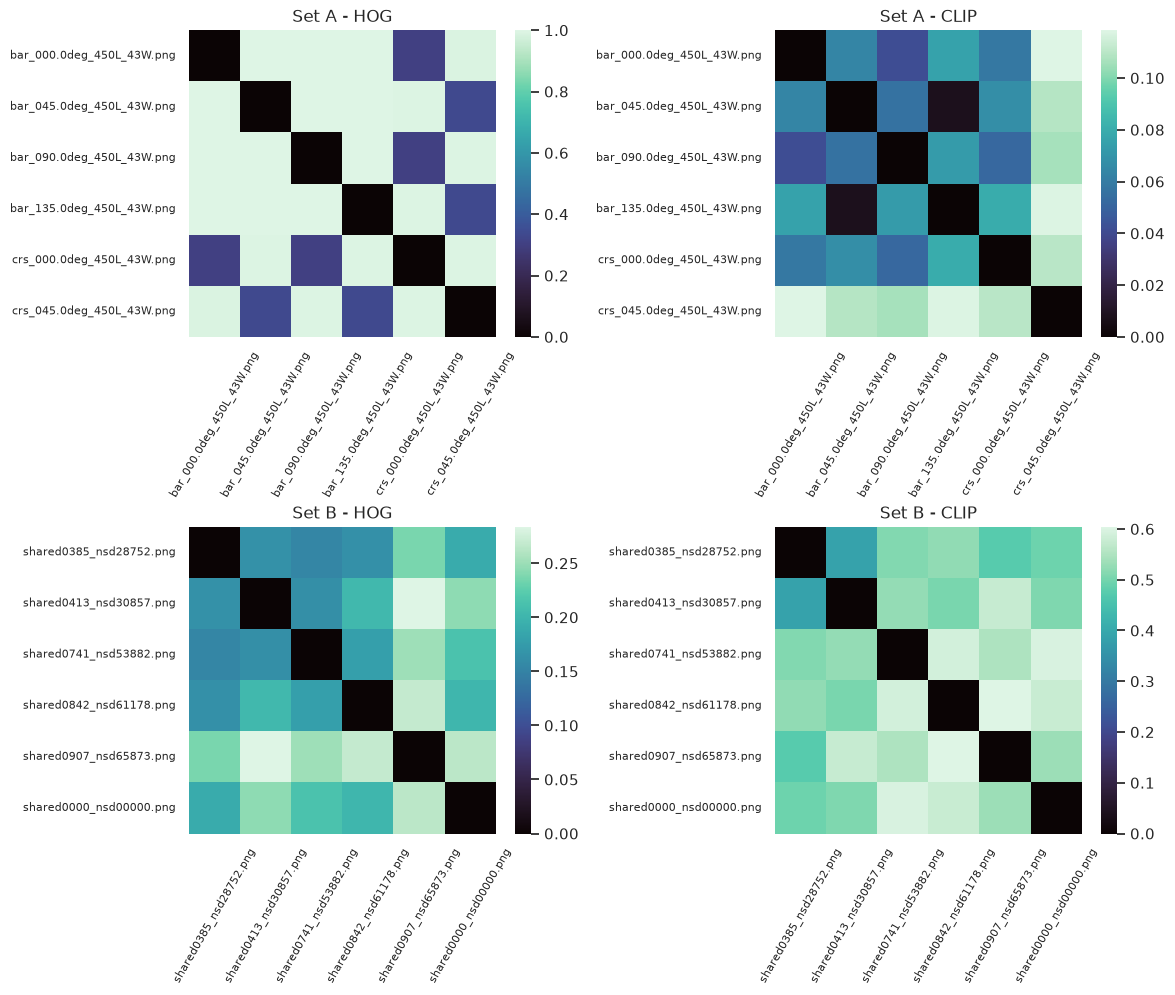

In [10]:
feature_rdms = {key: cosine_rdm(vectors) for key, vectors in feature_vectors.items()}
feature_models = [model for model in ('HOG', 'CLIP') if ('A', model) in feature_rdms]
fig, axes = plt.subplots(2, len(feature_models), figsize=(6 * len(feature_models), 10), squeeze=False)
for row, stimulus_set in enumerate(STIMULUS_SETS):
    labels = targets.loc[targets['stimulus_set'].eq(stimulus_set), 'target_name'].tolist()
    for column, feature_model in enumerate(feature_models):
        ax = axes[row, column]
        sns.heatmap(
            feature_rdms[(stimulus_set, feature_model)], square=True, cmap='mako',
            xticklabels=labels, yticklabels=labels, ax=ax,
        )
        ax.set_title(f'Set {stimulus_set} - {feature_model}')
        ax.tick_params(axis='x', rotation=60, labelsize=8)
        ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()

if 'CLIP' in feature_models:
    model_correlations = pd.DataFrame([
        {
            'stimulus_set': stimulus_set,
            'HOG_CLIP_rho': rdm_spearman(
                feature_rdms[(stimulus_set, 'HOG')],
                feature_rdms[(stimulus_set, 'CLIP')],
            ),
        }
        for stimulus_set in STIMULUS_SETS
    ])
    display(model_correlations)

With only six targets, each RDM contains 15 pairwise distances. HOG and CLIP may themselves be correlated. Their RDM correlation above is therefore part of the interpretation, and feature results should be presented as converging or contrasting probes rather than perfectly isolated processing levels.

## 5. Feature RSA across subjects

For every subject, ROI, set, task, and available feature model, we correlate the neural and feature RDM upper triangles. Exact target-label permutations accompany each RSA coefficient. Group inference again uses only subjects 02-08.

In [11]:
rsa_rows = []
for (subject, roi_name, stimulus_set, task), neural_rdm in neural_rdms.items():
    for feature_model in feature_models:
        test = exact_label_permutation_test(
            neural_rdm, feature_rdms[(stimulus_set, feature_model)]
        )
        rsa_rows.append({
            'subject': subject,
            'phase': 'pilot' if subject == PILOT_SUBJECT else 'heldout',
            'roi': roi_name,
            'stimulus_set': stimulus_set,
            'task': task,
            'feature_model': feature_model,
            'rsa_rho': test['observed'],
            'p_greater': test['p_greater'],
            'p_two_sided': test['p_two_sided'],
        })
rsa = pd.DataFrame(rsa_rows)
heldout_rsa = rsa[rsa['phase'].eq('heldout')].copy()
print('RSA rows:', len(rsa))
display(rsa.head(12))

RSA rows: 192


,subject,phase,roi,stimulus_set,task,feature_model,rsa_rho,p_greater,p_two_sided
0,1,pilot,nsdgeneral,A,vision,HOG,0.430498,0.033333,0.063889
1,1,pilot,nsdgeneral,A,vision,CLIP,0.135714,0.205556,0.420833
2,1,pilot,nsdgeneral,A,imagery,HOG,-0.401798,0.918056,0.105556
3,1,pilot,nsdgeneral,A,imagery,CLIP,0.271429,0.056944,0.144444
4,1,pilot,nsdgeneral,B,vision,HOG,0.053571,0.331944,0.736111
5,1,pilot,nsdgeneral,B,vision,CLIP,-0.139286,0.745833,0.529167
6,1,pilot,nsdgeneral,B,imagery,HOG,-0.096429,0.765278,0.491667
7,1,pilot,nsdgeneral,B,imagery,CLIP,-0.285714,0.962500,0.090278
8,1,pilot,early_visual,A,vision,HOG,0.457404,0.008333,0.047222
9,1,pilot,early_visual,A,vision,CLIP,0.046429,0.440278,0.820833


In [12]:
rsa_group_rows = []
for keys, frame in heldout_rsa.groupby(['stimulus_set', 'task', 'roi', 'feature_model']):
    values = frame['rsa_rho'].to_numpy()
    test = exact_sign_flip_test(values)
    rsa_group_rows.append({
        **dict(zip(['stimulus_set', 'task', 'roi', 'feature_model'], keys)),
        'n_subjects': len(values),
        'mean_rho': values.mean(),
        'median_rho': np.median(values),
        'p_greater': test['p_greater'],
        'p_two_sided': test['p_two_sided'],
    })
rsa_group_summary = pd.DataFrame(rsa_group_rows)
display(rsa_group_summary.query("stimulus_set == 'B'").sort_values(['task', 'roi', 'feature_model']))

,stimulus_set,task,roi,feature_model,n_subjects,mean_rho,median_rho,p_greater,p_two_sided
12,B,imagery,early_visual,CLIP,7,-0.189796,-0.135714,1.000000,0.015625
13,B,imagery,early_visual,HOG,7,-0.058163,-0.096429,0.898438,0.234375
14,B,imagery,higher_visual,CLIP,7,-0.020408,-0.046429,0.640625,0.750000
15,B,imagery,higher_visual,HOG,7,0.111735,0.150000,0.093750,0.187500
16,B,imagery,nsdgeneral,CLIP,7,-0.037245,0.057143,0.640625,0.734375
17,B,imagery,nsdgeneral,HOG,7,0.050510,0.050000,0.281250,0.562500
18,B,vision,early_visual,CLIP,7,-0.258673,-0.342857,0.992188,0.031250
19,B,vision,early_visual,HOG,7,0.107653,0.032143,0.054688,0.109375
20,B,vision,higher_visual,CLIP,7,-0.105102,-0.075000,0.984375,0.046875
21,B,vision,higher_visual,HOG,7,0.025510,-0.010714,0.320312,0.640625


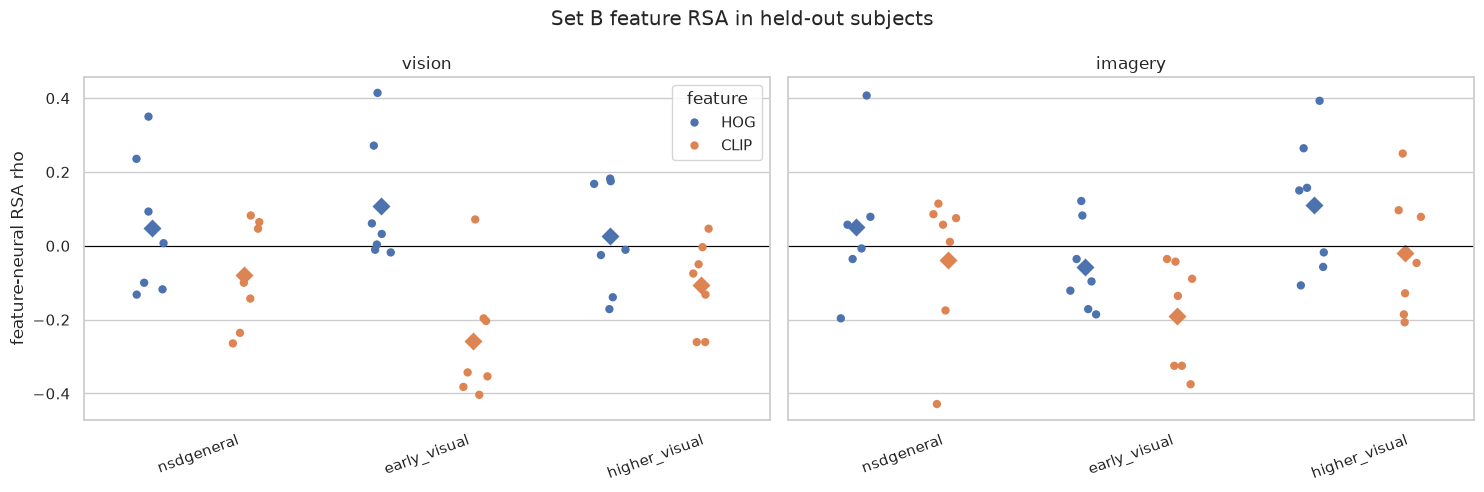

In [13]:
set_b_heldout = heldout_rsa[heldout_rsa['stimulus_set'].eq('B')]
dodge_features = len(feature_models) > 1
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, task in zip(axes, ('vision', 'imagery')):
    frame = set_b_heldout[set_b_heldout['task'].eq(task)]
    sns.stripplot(
        data=frame, x='roi', y='rsa_rho', hue='feature_model', order=ROI_ORDER,
        hue_order=feature_models, dodge=dodge_features, jitter=.14, size=6, ax=ax,
    )
    sns.pointplot(
        data=frame, x='roi', y='rsa_rho', hue='feature_model', order=ROI_ORDER,
        hue_order=feature_models, dodge=.4 if dodge_features else False,
        errorbar=None, markers='D',
        linestyles='none', ax=ax, legend=False,
    )
    ax.axhline(0, color='black', linewidth=.8)
    ax.set(title=task, xlabel='', ylabel='feature-neural RSA rho')
    ax.tick_params(axis='x', rotation=20)
right_legend = axes[1].get_legend()
if right_legend is not None:
    right_legend.remove()
axes[0].legend(title='feature')
fig.suptitle('Set B feature RSA in held-out subjects')
plt.tight_layout()

## 6. Planned feature contrasts

The first contrast asks whether CLIP explains Set B imagery geometry better than HOG in higher visual cortex. The second returns to the original transfer/drop formulation: is the vision-to-imagery loss for early-visual HOG larger than the loss for higher-visual CLIP? These are small-sample explanatory tests, secondary to the held-out neural-transfer result.

In [14]:
feature_contrasts = []
if 'CLIP' in feature_models:
    imagery_higher = (
        heldout_rsa.query("stimulus_set == 'B' and task == 'imagery' and roi == 'higher_visual'")
        .pivot(index='subject', columns='feature_model', values='rsa_rho')
    )
    semantic_advantage = (imagery_higher['CLIP'] - imagery_higher['HOG']).to_numpy()
    semantic_test = exact_sign_flip_test(semantic_advantage)
    feature_contrasts.append({
        'contrast': 'Set B imagery: higher-visual CLIP minus HOG',
        'mean_effect': semantic_advantage.mean(),
        'p_greater': semantic_test['p_greater'],
        'p_two_sided': semantic_test['p_two_sided'],
    })

    set_b_wide_rsa = (
        heldout_rsa[heldout_rsa['stimulus_set'].eq('B')]
        .pivot(index=['subject', 'roi', 'feature_model'], columns='task', values='rsa_rho')
        .assign(drop=lambda frame: frame['vision'] - frame['imagery'])
    )
    early_hog_drop = set_b_wide_rsa.xs(('early_visual', 'HOG'), level=('roi', 'feature_model'))['drop']
    higher_clip_drop = set_b_wide_rsa.xs(('higher_visual', 'CLIP'), level=('roi', 'feature_model'))['drop']
    drop_contrast = (early_hog_drop - higher_clip_drop).to_numpy()
    drop_test = exact_sign_flip_test(drop_contrast)
    feature_contrasts.append({
        'contrast': 'Set B drop: early HOG minus higher CLIP',
        'mean_effect': drop_contrast.mean(),
        'p_greater': drop_test['p_greater'],
        'p_two_sided': drop_test['p_two_sided'],
    })
else:
    print('CLIP was unavailable, so CLIP-HOG contrasts are not computed.')

feature_contrasts = pd.DataFrame(feature_contrasts)
display(feature_contrasts)

,contrast,mean_effect,p_greater,p_two_sided
0,Set B imagery: higher-visual CLIP minus HOG,-0.132143,0.992188,0.031250
1,Set B drop: early HOG minus higher CLIP,0.250510,0.039062,0.078125


## 7. Save compact results

The beta cache stays under `data/nsd/derived` and should not be committed. The files below are compact tables and RDMs suitable for version control and later figures.

In [15]:
neural_metrics.to_csv(OUTPUT_DIR / 'neural_transfer_subject_level.csv', index=False)
neural_group_summary.to_csv(OUTPUT_DIR / 'neural_transfer_group_summary.csv', index=False)
confirmatory_tests.to_csv(OUTPUT_DIR / 'confirmatory_neural_tests.csv', index=False)
rsa.to_csv(OUTPUT_DIR / 'feature_rsa_subject_level.csv', index=False)
rsa_group_summary.to_csv(OUTPUT_DIR / 'feature_rsa_group_summary.csv', index=False)
feature_contrasts.to_csv(OUTPUT_DIR / 'feature_contrasts.csv', index=False)
np.savez_compressed(
    OUTPUT_DIR / 'neural_rdms_all_subjects.npz',
    **{
        f'subj{subject:02d}__{roi}__set{stimulus_set}__{task}': rdm
        for (subject, roi, stimulus_set, task), rdm in neural_rdms.items()
    },
)
np.savez_compressed(
    OUTPUT_DIR / 'feature_rdms.npz',
    **{f'set{stimulus_set}__{model}': rdm for (stimulus_set, model), rdm in feature_rdms.items()},
)
print('Saved compact results to:', OUTPUT_DIR)

Saved compact results to: /home/jovyan/NHprojectNSDimagery/outputs/03_group_transfer_feature_rsa


## 8. Interpretation guide

Read the results in this order:

1. **Reliability:** Are held-out Set B RDMs reproducible, particularly imagery run-to-run?
2. **Neural transfer:** Is Set B higher-visual vision-imagery correlation consistently positive in subjects 02-08?
3. **Anatomy:** Is transfer larger in higher than early visual cortex?
4. **Feature explanation:** Does CLIP outperform HOG for Set B imagery in higher visual cortex?
5. **Transfer/drop:** Is low-level early-visual alignment lost more strongly than higher-level CLIP alignment?

A positive sequence supports the refined claim that natural-image geometry transfers from perception to imagery and is relatively semantic in higher visual cortex. Mixed or null held-out results do not justify tuning the analysis around `subj01`; the defensible conclusion becomes that current NSD-Imagery sampling is insufficient for stable population-level representational geometry, motivating more repeated imagery data.

Either conclusion should include individual-subject points, exact tests, and the explicit limitation of six targets and seven held-out participants.

## 9. Full 18-target neural RDMs across subjects and ROIs

The original analysis deliberately estimated each six-target RDM separately. This appended section asks a complementary exploratory question: what happens when all 18 target-average patterns are placed in one common RDM?

The off-diagonal blocks are computable because all targets use the same sampled voxels within a subject and ROI. They are nevertheless partly confounded with run: A, B, and C were acquired in separate runs. We therefore summarize vision-imagery agreement using all distances, within-set distances, between-set distances, and a block-residual correlation that removes the six set-pair block means.

The existing beta cache is reused. No beta files are duplicated, and none of the earlier cells or confirmatory analyses are changed.


In [16]:
FULL_SET_ORDER = ('A', 'B', 'C')
FULL_TASK_ORDER = ('vision', 'imagery')


def full_rdm_from_events(frame, patterns):
    # Average all available targets in set/target order.
    centroid_rows = []
    metadata_rows = []
    for (stimulus_set, target_number), index_labels in frame.groupby(
        ['stimulus_set', 'target_number'], sort=True
    ).groups.items():
        index_labels = np.asarray(index_labels, dtype=int)
        first = frame.loc[index_labels[0]]
        centroid_rows.append(patterns[index_labels].mean(axis=0))
        metadata_rows.append({
            'stimulus_set': stimulus_set,
            'target_number': int(target_number),
            'target_code': first['target_code'],
            'target_name': first['target_name'],
            'n_trials': len(index_labels),
        })
    metadata = pd.DataFrame(metadata_rows).sort_values(
        ['stimulus_set', 'target_number']
    ).reset_index(drop=True)
    centroids = np.stack(centroid_rows)
    assert len(metadata) in (12, 18)
    return correlation_rdm(centroids), metadata


def full_pair_metadata(set_labels):
    row, column = np.triu_indices(len(set_labels), k=1)
    set_labels = np.asarray(set_labels)
    blocks = np.asarray([
        ''.join(sorted((set_labels[i], set_labels[j])))
        for i, j in zip(row, column)
    ])
    return row, column, blocks


def vector_spearman(first, second):
    return float(pd.Series(first).corr(pd.Series(second), method='spearman'))


def block_residual_spearman(first, second, blocks):
    # Partial Spearman correlation after removing set-pair block means.
    first_rank = pd.Series(first).rank(method='average').to_numpy()
    second_rank = pd.Series(second).rank(method='average').to_numpy()
    block_design = pd.get_dummies(
        pd.Series(blocks), drop_first=True, dtype=float
    ).to_numpy()
    design = np.column_stack([np.ones(len(blocks)), block_design])
    first_residual = first_rank - design @ np.linalg.lstsq(
        design, first_rank, rcond=None
    )[0]
    second_residual = second_rank - design @ np.linalg.lstsq(
        design, second_rank, rcond=None
    )[0]
    return float(np.corrcoef(first_residual, second_residual)[0, 1])


def full_rdm_scope_metrics(first_rdm, second_rdm, set_labels):
    row, column, blocks = full_pair_metadata(set_labels)
    first = first_rdm[row, column]
    second = second_rdm[row, column]
    within = np.asarray([block[0] == block[1] for block in blocks])
    return {
        'all': vector_spearman(first, second),
        'within_set': vector_spearman(first[within], second[within]),
        'between_set': vector_spearman(first[~within], second[~within]),
        'block_residual': block_residual_spearman(first, second, blocks),
    }


def group_sign_flip_summary(frame, group_columns, value_column='rho'):
    rows = []
    for key, group in frame.groupby(group_columns, sort=True):
        key = key if isinstance(key, tuple) else (key,)
        values = group[value_column].dropna().to_numpy()
        test = exact_sign_flip_test(values)
        row = dict(zip(group_columns, key))
        row.update({
            'n_subjects': len(values),
            'mean_rho': float(values.mean()),
            'median_rho': float(np.median(values)),
            'p_greater': test['p_greater'],
            'p_two_sided': test['p_two_sided'],
        })
        rows.append(row)
    return pd.DataFrame(rows)


In [18]:
full_neural_rdms = {}
full_neural_metric_rows = []
full_neural_reliability_rows = []
full_target_metadata = None

for subject in SUBJECTS:
    print(f'\nfull RDM: subj{subject:02d}')
    events_full = build_event_table(DATA_ROOT, subject).reset_index(drop=True)
    for roi_index, roi_name in enumerate(ROI_ORDER):
        all_betas, coordinates = load_or_extract_roi_betas(
            subject, roi_name, roi_index
        )
        trial_patterns = all_betas[events_full['beta_index'].to_numpy()]
        normalized = zscore_within_groups(
            trial_patterns, events_full['run_name'].to_numpy()
        )

        task_rdms = {}
        task_metadata = {}
        for task in FULL_TASK_ORDER:
            frame = events_full[events_full['task'].eq(task)]
            rdm, metadata = full_rdm_from_events(frame, normalized)
            assert len(metadata) == 18
            task_rdms[task] = rdm
            task_metadata[task] = metadata
            full_neural_rdms[(subject, roi_name, task)] = rdm

        identity_columns = [
            'stimulus_set', 'target_number', 'target_code', 'target_name'
        ]
        assert task_metadata['vision'][identity_columns].equals(
            task_metadata['imagery'][identity_columns]
        )
        if full_target_metadata is None:
            full_target_metadata = task_metadata['vision'].copy()
        else:
            assert full_target_metadata[identity_columns].equals(
                task_metadata['vision'][identity_columns]
            )

        set_labels = task_metadata['vision']['stimulus_set'].to_numpy()
        transfer_metrics = full_rdm_scope_metrics(
            task_rdms['vision'], task_rdms['imagery'], set_labels
        )
        for scope, rho in transfer_metrics.items():
            full_neural_metric_rows.append({
                'subject': subject,
                'phase': 'pilot' if subject == PILOT_SUBJECT else 'heldout',
                'roi': roi_name,
                'scope': scope,
                'rho': rho,
                'n_voxels': len(coordinates),
            })

        reliability_partitions = {
            'vision odd/even': (
                events_full[
                    events_full['task'].eq('vision')
                    & events_full['repeat'].mod(2).eq(1)
                ],
                events_full[
                    events_full['task'].eq('vision')
                    & events_full['repeat'].mod(2).eq(0)
                ],
            ),
            'imagery run 1/run 2': (
                events_full[
                    events_full['task'].eq('imagery')
                    & events_full['run_name'].str.endswith('_1')
                ],
                events_full[
                    events_full['task'].eq('imagery')
                    & events_full['run_name'].str.endswith('_2')
                ],
            ),
        }
        for comparison, (first_frame, second_frame) in reliability_partitions.items():
            first_rdm, first_metadata = full_rdm_from_events(
                first_frame, normalized
            )
            second_rdm, second_metadata = full_rdm_from_events(
                second_frame, normalized
            )
            assert first_metadata[identity_columns].equals(
                second_metadata[identity_columns]
            )
            for scope, rho in full_rdm_scope_metrics(
                first_rdm, second_rdm, set_labels
            ).items():
                full_neural_reliability_rows.append({
                    'subject': subject,
                    'phase': 'pilot' if subject == PILOT_SUBJECT else 'heldout',
                    'roi': roi_name,
                    'comparison': comparison,
                    'scope': scope,
                    'rho': rho,
                })

full_neural_metrics = pd.DataFrame(full_neural_metric_rows)
full_neural_reliability = pd.DataFrame(full_neural_reliability_rows)
heldout_full_neural = full_neural_metrics[
    full_neural_metrics['phase'].eq('heldout')
].copy()
full_neural_group_summary = group_sign_flip_summary(
    heldout_full_neural, ['roi', 'scope']
)

display(full_neural_group_summary)
display(
    full_neural_reliability[
        full_neural_reliability['phase'].eq('heldout')
    ]
    .groupby(['roi', 'comparison', 'scope'])['rho']
    .agg(['mean', 'median'])
    .reset_index()
)



full RDM: subj01
  nsdgeneral: cache hit, 1200 voxels
  early_visual: cache hit, 1200 voxels
  higher_visual: cache hit, 1200 voxels

full RDM: subj02
  nsdgeneral: cache hit, 1200 voxels
  early_visual: cache hit, 1200 voxels
  higher_visual: cache hit, 1200 voxels

full RDM: subj03
  nsdgeneral: cache hit, 1200 voxels
  early_visual: cache hit, 1200 voxels
  higher_visual: cache hit, 1200 voxels

full RDM: subj04
  nsdgeneral: cache hit, 1200 voxels
  early_visual: cache hit, 1200 voxels
  higher_visual: cache hit, 1200 voxels

full RDM: subj05
  nsdgeneral: cache hit, 1200 voxels
  early_visual: cache hit, 1200 voxels
  higher_visual: cache hit, 1200 voxels

full RDM: subj06
  nsdgeneral: cache hit, 1200 voxels
  early_visual: cache hit, 1200 voxels
  higher_visual: cache hit, 1200 voxels

full RDM: subj07
  nsdgeneral: cache hit, 1200 voxels
  early_visual: cache hit, 1200 voxels
  higher_visual: cache hit, 1200 voxels

full RDM: subj08
  nsdgeneral: cache hit, 1200 voxels
  early

,roi,scope,n_subjects,mean_rho,median_rho,p_greater,p_two_sided
0,early_visual,all,7,0.337001,0.341918,0.007812,0.015625
1,early_visual,between_set,7,0.006260,-0.010337,0.414062,0.828125
2,early_visual,block_residual,7,0.068517,0.073390,0.046875,0.093750
3,early_visual,within_set,7,0.266158,0.240316,0.007812,0.015625
4,higher_visual,all,7,0.398699,0.381750,0.007812,0.015625
5,higher_visual,between_set,7,-0.062821,-0.051892,0.890625,0.234375
6,higher_visual,block_residual,7,-0.008175,0.043141,0.578125,0.859375
7,higher_visual,within_set,7,0.226482,0.195257,0.007812,0.015625
8,nsdgeneral,all,7,0.390990,0.389443,0.007812,0.015625
9,nsdgeneral,between_set,7,-0.029820,-0.034773,0.828125,0.359375


,roi,comparison,scope,mean,median
0,early_visual,imagery run 1/run 2,all,0.336431,0.326937
1,early_visual,imagery run 1/run 2,between_set,0.021362,-0.044395
2,early_visual,imagery run 1/run 2,block_residual,0.019452,-0.003029
3,early_visual,imagery run 1/run 2,within_set,0.043365,0.068511
4,early_visual,vision odd/even,all,0.277430,0.290174
5,early_visual,vision odd/even,between_set,0.132866,0.141873
6,early_visual,vision odd/even,block_residual,0.162898,0.184278
7,early_visual,vision odd/even,within_set,0.257877,0.251779
8,higher_visual,imagery run 1/run 2,all,0.433544,0.455909
9,higher_visual,imagery run 1/run 2,between_set,0.086725,0.143759


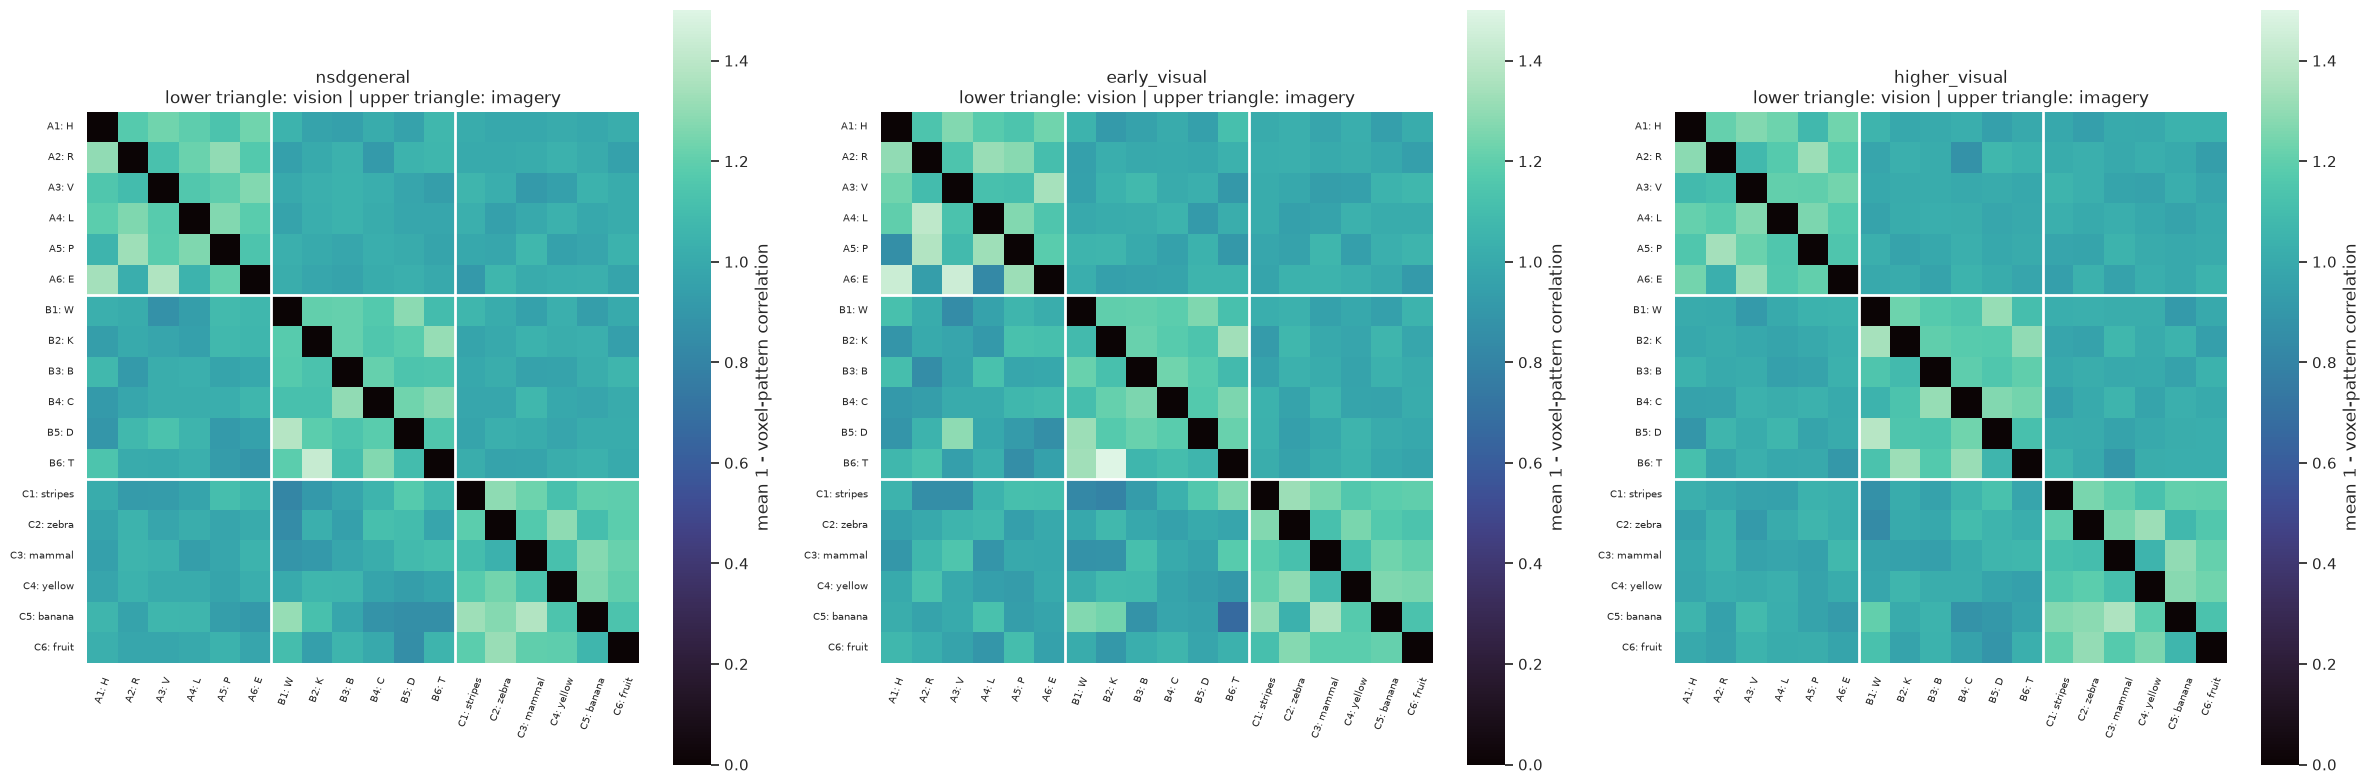

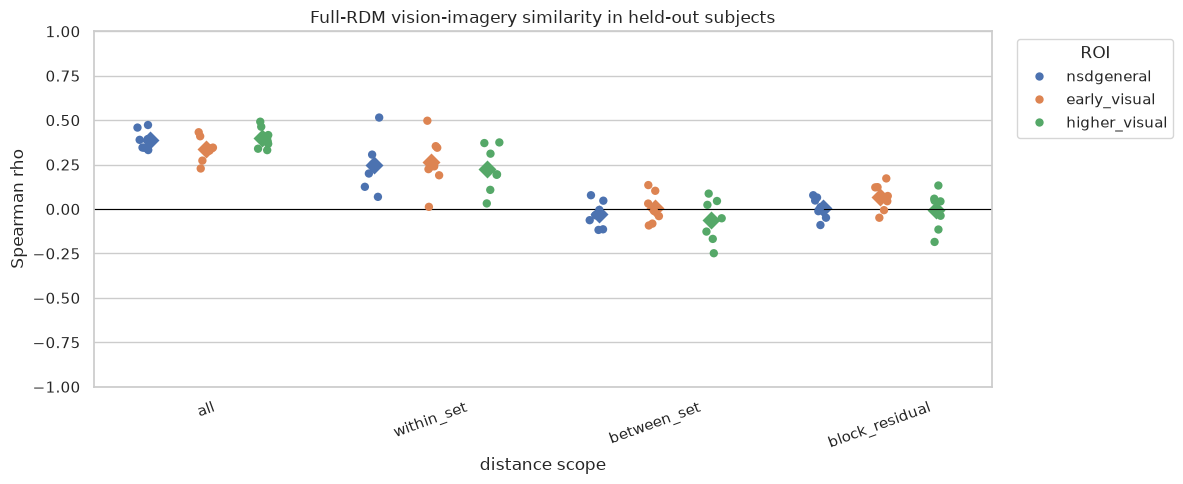

In [19]:
full_target_labels = [
    (
        f"{row.stimulus_set}{row.target_number}: {row.target_name}"
        if row.stimulus_set == 'C'
        else f"{row.stimulus_set}{row.target_number}: {row.target_code}"
    )
    for row in full_target_metadata.itertuples(index=False)
]
heldout_subjects = [subject for subject in SUBJECTS if subject != PILOT_SUBJECT]
group_mean_rdms = {
    (roi_name, task): np.mean([
        full_neural_rdms[(subject, roi_name, task)]
        for subject in heldout_subjects
    ], axis=0)
    for roi_name in ROI_ORDER
    for task in FULL_TASK_ORDER
}
group_rdm_vmax = max(float(rdm.max()) for rdm in group_mean_rdms.values())

fig, axes = plt.subplots(1, len(ROI_ORDER), figsize=(24, 8))
for ax, roi_name in zip(axes, ROI_ORDER):
    vision_mean = group_mean_rdms[(roi_name, 'vision')]
    imagery_mean = group_mean_rdms[(roi_name, 'imagery')]
    split_triangle = (
        np.tril(vision_mean, k=-1)
        + np.triu(imagery_mean, k=1)
    )
    sns.heatmap(
        split_triangle,
        square=True,
        cmap='mako',
        vmin=0,
        vmax=group_rdm_vmax,
        xticklabels=full_target_labels,
        yticklabels=full_target_labels,
        cbar_kws={'label': 'mean 1 - voxel-pattern correlation'},
        ax=ax,
    )
    for boundary in (6, 12):
        ax.axhline(boundary, color='white', linewidth=2)
        ax.axvline(boundary, color='white', linewidth=2)
    ax.set_title(
        f'{roi_name}\nlower triangle: vision | upper triangle: imagery'
    )
    ax.tick_params(axis='x', rotation=70, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)
plt.tight_layout()

fig, ax = plt.subplots(figsize=(12, 5))
scope_order = ['all', 'within_set', 'between_set', 'block_residual']
sns.stripplot(
    data=heldout_full_neural,
    x='scope',
    y='rho',
    hue='roi',
    order=scope_order,
    hue_order=ROI_ORDER,
    dodge=True,
    jitter=.12,
    size=6,
    ax=ax,
)
sns.pointplot(
    data=heldout_full_neural,
    x='scope',
    y='rho',
    hue='roi',
    order=scope_order,
    hue_order=ROI_ORDER,
    dodge=.5,
    errorbar=None,
    markers='D',
    linestyles='none',
    legend=False,
    ax=ax,
)
ax.axhline(0, color='black', linewidth=.8)
ax.set(
    title='Full-RDM vision-imagery similarity in held-out subjects',
    xlabel='distance scope',
    ylabel='Spearman rho',
    ylim=(-1, 1),
)
ax.tick_params(axis='x', rotation=20)
ax.legend(title='ROI', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()


## 10. Full feature RDMs

Two feature atlases are possible:

- **HOG images A+B (12 targets):** Sets A and B have fixed image files, so their HOG vectors can be concatenated directly. Set C has no single fixed image and is omitted.
- **CLIP images A+B plus concept text C (18 targets):** CLIP was trained to place images and text in a shared projected space. The six Set C labels are embedded with the transparent prompt `a photo of {concept}` and concatenated with the existing A/B image embeddings.

The mixed CLIP RDM is exploratory. A visible A/B-versus-C division can reflect the known CLIP image-text modality gap as well as semantic structure. The within-set and block-residual RSA results are therefore more informative than the overall 153-distance correlation.


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 23239.43it/s]
[transformers] CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
logit_scale         

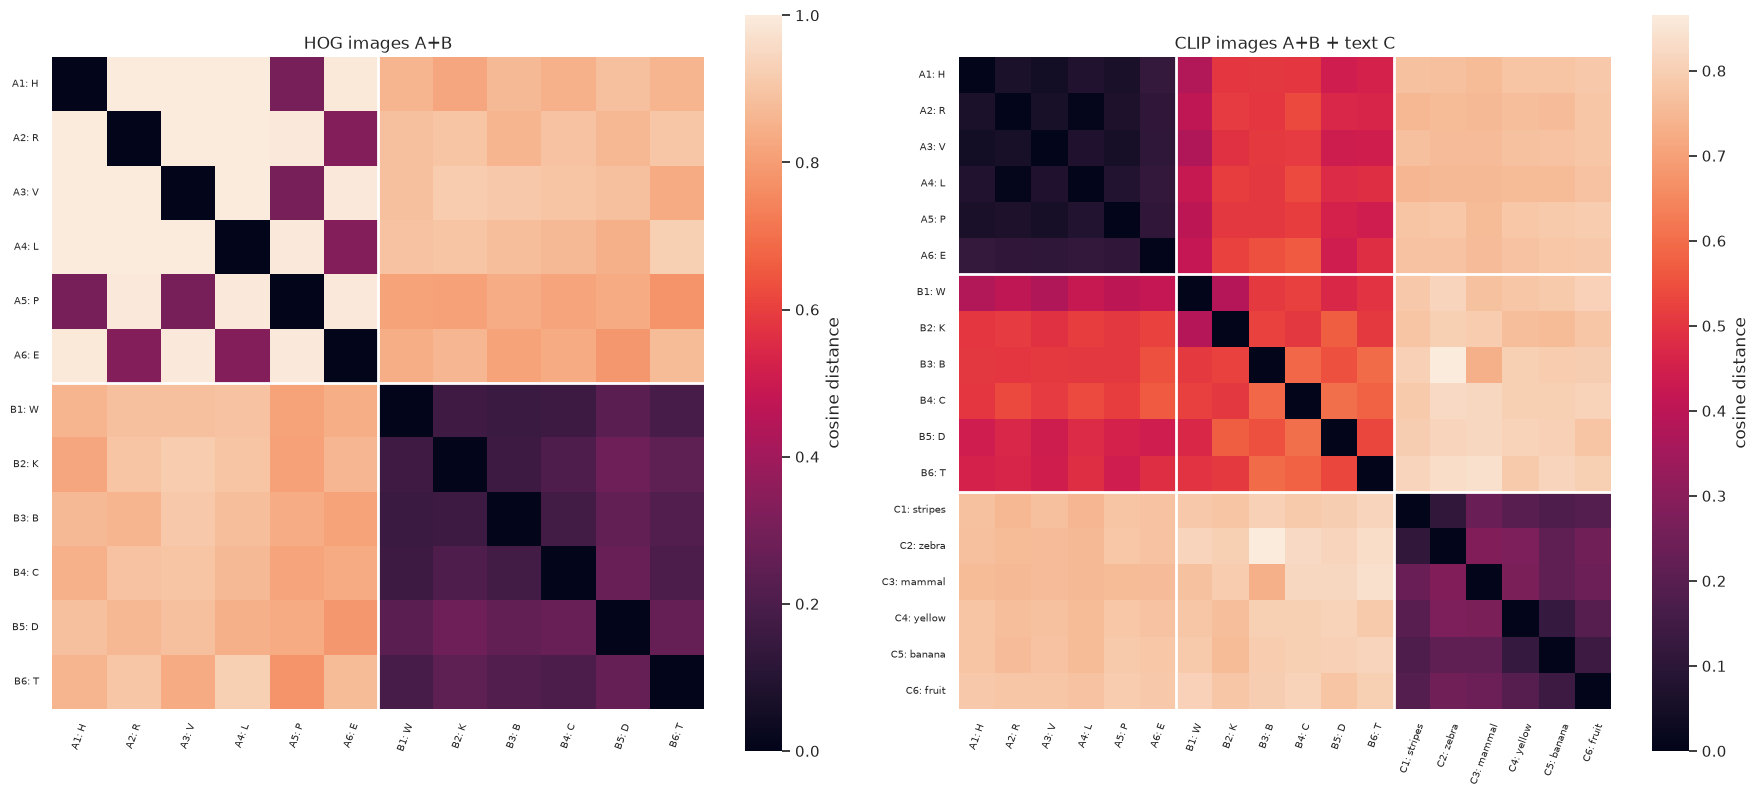

In [20]:
full_targets = (
    load_target_table(DATA_ROOT)
    .sort_values(['stimulus_set', 'target_number'])
    .reset_index(drop=True)
)
assert len(full_targets) == 18

full_feature_specs = {}

# HOG is defined only for the 12 fixed images in Sets A and B.
if all((stimulus_set, 'HOG') in feature_vectors for stimulus_set in ('A', 'B')):
    hog_full_vectors = np.vstack([
        feature_vectors[('A', 'HOG')],
        feature_vectors[('B', 'HOG')],
    ])
    full_feature_specs['HOG images A+B'] = {
        'rdm': cosine_rdm(hog_full_vectors),
        'indices': np.arange(12),
        'set_labels': np.repeat(['A', 'B'], 6),
        'labels': full_target_labels[:12],
    }

# Reuse A/B CLIP image embeddings and add six projected text embeddings for C.
full_clip_error = None
if all((stimulus_set, 'CLIP') in feature_vectors for stimulus_set in ('A', 'B')):
    try:
        import torch
        from transformers import CLIPTextModelWithProjection

        concept_frame = full_targets[full_targets['stimulus_set'].eq('C')]
        concept_prompts = [
            f"a photo of {name.replace('_', ' ')}"
            for name in concept_frame['target_name']
        ]
        text_model = CLIPTextModelWithProjection.from_pretrained(
            CLIP_MODEL_NAME
        ).eval()
        text_inputs = processor(
            text=concept_prompts,
            padding=True,
            return_tensors='pt',
        )
        text_inputs = {
            key: value
            for key, value in text_inputs.items()
            if key in ('input_ids', 'attention_mask')
        }
        with torch.inference_mode():
            concept_vectors = text_model(**text_inputs).text_embeds
            concept_vectors = concept_vectors / concept_vectors.norm(
                dim=1, keepdim=True
            )
        clip_full_vectors = np.vstack([
            feature_vectors[('A', 'CLIP')],
            feature_vectors[('B', 'CLIP')],
            concept_vectors.cpu().numpy(),
        ])
        assert clip_full_vectors.shape[0] == 18
        full_feature_specs['CLIP images A+B + text C'] = {
            'rdm': cosine_rdm(clip_full_vectors),
            'indices': np.arange(18),
            'set_labels': np.repeat(['A', 'B', 'C'], 6),
            'labels': full_target_labels,
            'concept_prompts': concept_prompts,
        }
        del text_model
    except Exception as error:
        full_clip_error = error
        print('Full CLIP image-text RDM unavailable; HOG analysis can continue.')
        print(type(error).__name__ + ':', error)

if not full_feature_specs:
    raise RuntimeError('No full feature RDM could be constructed.')

fig, axes = plt.subplots(
    1, len(full_feature_specs),
    figsize=(9 * len(full_feature_specs), 8),
    squeeze=False,
)
for ax, (feature_name, spec) in zip(axes.flat, full_feature_specs.items()):
    sns.heatmap(
        spec['rdm'],
        square=True,
        cmap='rocket',
        xticklabels=spec['labels'],
        yticklabels=spec['labels'],
        cbar_kws={'label': 'cosine distance'},
        ax=ax,
    )
    for boundary in range(6, len(spec['labels']), 6):
        ax.axhline(boundary, color='white', linewidth=2)
        ax.axvline(boundary, color='white', linewidth=2)
    ax.set_title(feature_name)
    ax.tick_params(axis='x', rotation=70, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)
plt.tight_layout()


,feature_model,roi,task,scope,n_subjects,mean_rho,median_rho,p_greater,p_two_sided
0,CLIP images A+B + text C,early_visual,imagery,all,7,-0.371897,-0.376627,1.000000,0.015625
1,CLIP images A+B + text C,early_visual,imagery,between_set,7,-0.014267,-0.008403,0.835938,0.343750
2,CLIP images A+B + text C,early_visual,imagery,block_residual,7,-0.027085,-0.016187,0.898438,0.218750
3,CLIP images A+B + text C,early_visual,imagery,within_set,7,-0.038942,-0.046377,0.976562,0.062500
4,CLIP images A+B + text C,early_visual,vision,all,7,-0.332472,-0.347011,1.000000,0.015625
5,CLIP images A+B + text C,early_visual,vision,between_set,7,-0.002176,0.002620,0.562500,0.890625
6,CLIP images A+B + text C,early_visual,vision,block_residual,7,-0.035104,-0.037960,0.992188,0.031250
7,CLIP images A+B + text C,early_visual,vision,within_set,7,-0.084152,-0.082872,1.000000,0.015625
8,CLIP images A+B + text C,higher_visual,imagery,all,7,-0.430222,-0.427436,1.000000,0.015625
9,CLIP images A+B + text C,higher_visual,imagery,between_set,7,-0.014169,-0.024065,0.929688,0.156250


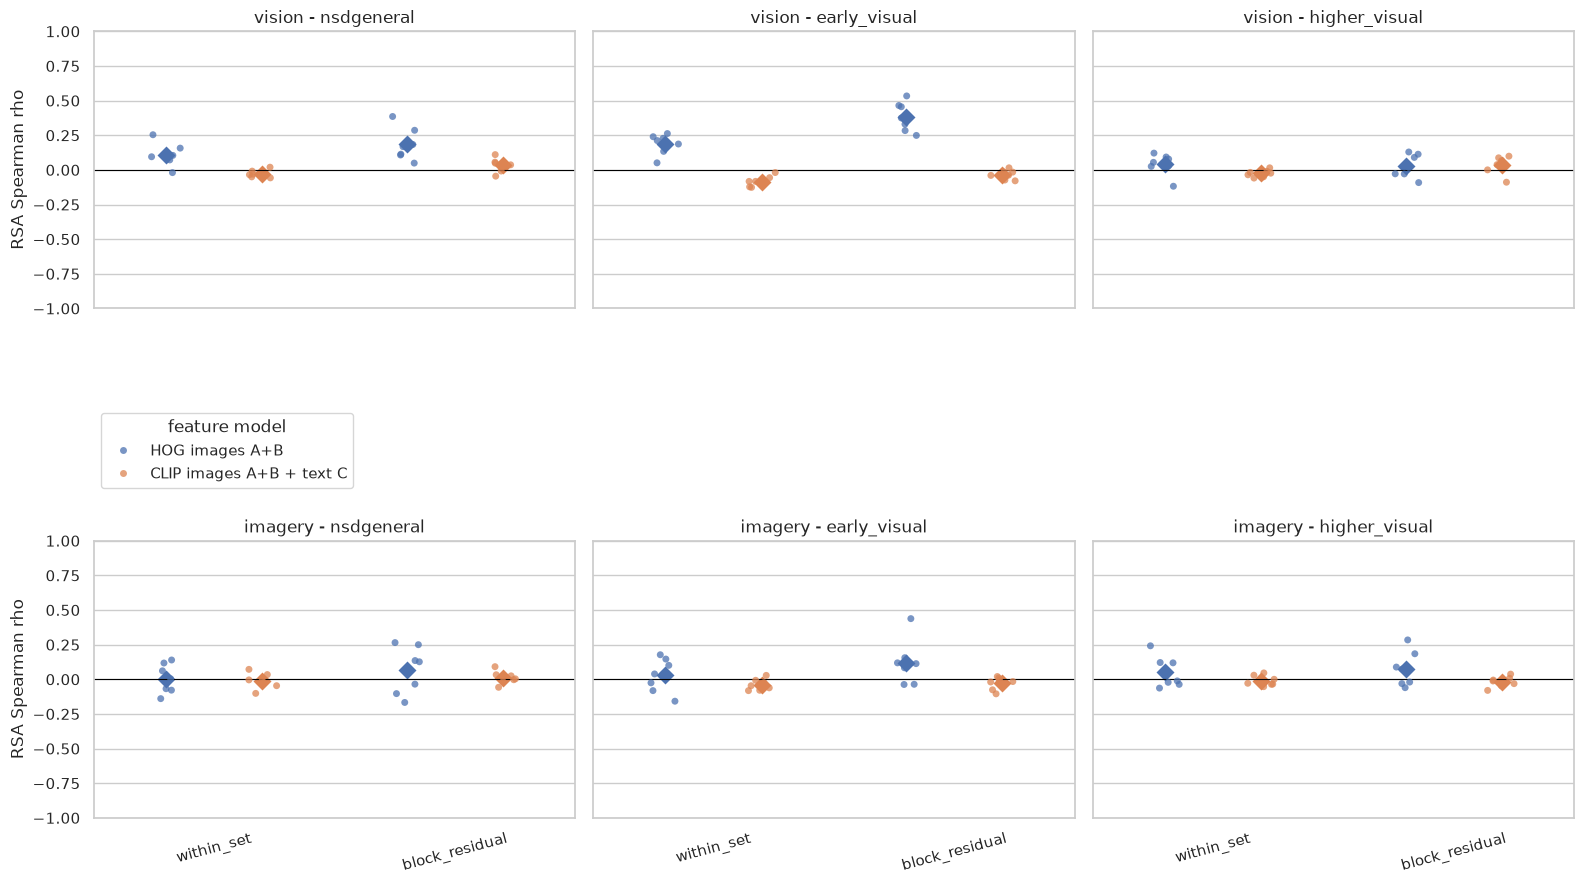

In [21]:
full_feature_rsa_rows = []
for (subject, roi_name, task), neural_rdm in full_neural_rdms.items():
    for feature_name, spec in full_feature_specs.items():
        indices = spec['indices']
        neural_subset = neural_rdm[np.ix_(indices, indices)]
        metrics = full_rdm_scope_metrics(
            neural_subset, spec['rdm'], spec['set_labels']
        )
        for scope, rho in metrics.items():
            full_feature_rsa_rows.append({
                'subject': subject,
                'phase': 'pilot' if subject == PILOT_SUBJECT else 'heldout',
                'roi': roi_name,
                'task': task,
                'feature_model': feature_name,
                'scope': scope,
                'rsa_rho': rho,
                'n_targets': len(indices),
            })

full_feature_rsa = pd.DataFrame(full_feature_rsa_rows)
heldout_full_feature_rsa = full_feature_rsa[
    full_feature_rsa['phase'].eq('heldout')
].copy()
full_feature_rsa_group_summary = group_sign_flip_summary(
    heldout_full_feature_rsa,
    ['feature_model', 'roi', 'task', 'scope'],
    value_column='rsa_rho',
)
display(full_feature_rsa_group_summary)

plot_frame = heldout_full_feature_rsa[
    heldout_full_feature_rsa['scope'].isin(
        ['within_set', 'block_residual']
    )
]
fig, axes = plt.subplots(
    len(FULL_TASK_ORDER), len(ROI_ORDER),
    figsize=(16, 9),
    sharex=True,
    sharey=True,
)
scope_plot_order = ['within_set', 'block_residual']
for row_index, task in enumerate(FULL_TASK_ORDER):
    for column_index, roi_name in enumerate(ROI_ORDER):
        ax = axes[row_index, column_index]
        frame = plot_frame[
            plot_frame['task'].eq(task)
            & plot_frame['roi'].eq(roi_name)
        ]
        sns.stripplot(
            data=frame,
            x='scope',
            y='rsa_rho',
            hue='feature_model',
            order=scope_plot_order,
            dodge=True,
            jitter=.12,
            size=5,
            alpha=.75,
            ax=ax,
        )
        sns.pointplot(
            data=frame,
            x='scope',
            y='rsa_rho',
            hue='feature_model',
            order=scope_plot_order,
            dodge=.4,
            errorbar=None,
            markers='D',
            linestyles='none',
            legend=False,
            ax=ax,
        )
        ax.axhline(0, color='black', linewidth=.8)
        ax.set(
            title=f'{task} - {roi_name}',
            xlabel='',
            ylabel='RSA Spearman rho' if column_index == 0 else '',
            ylim=(-1, 1),
        )
        ax.tick_params(axis='x', rotation=15)
        legend = ax.get_legend()
        if legend is not None and (row_index, column_index) != (0, 0):
            legend.remove()
axes[0, 0].legend(
    title='feature model',
    bbox_to_anchor=(0, -0.35),
    loc='upper left',
)
plt.tight_layout()


### Interpretation order

1. Inspect full-RDM split reliability, especially imagery run 1 versus run 2. A visually striking but irreproducible block pattern is not a stable representational result.
2. Compare the `all` neural vision-imagery correlation with `within_set` and `block_residual`. If only `all` is positive, the result is mainly the shared A/B/C set/run partition.
3. Treat Set C as concept-level: its vision pattern averages varying exemplars, whereas its feature representation here is CLIP text.
4. For HOG and mixed-modal CLIP, inspect within-set and block-residual RSA before the overall value. The overall value can be inflated by coarse image-type, run, or modality separation.
5. These additions are exploratory visual and diagnostic analyses. They do not replace Notebook 03's original held-out Set B test or Notebook 04's measurement-first evidence hierarchy.


In [22]:
full_target_metadata.to_csv(
    OUTPUT_DIR / 'full18_target_metadata.csv', index=False
)
full_neural_metrics.to_csv(
    OUTPUT_DIR / 'full18_neural_transfer_subject_level.csv', index=False
)
full_neural_group_summary.to_csv(
    OUTPUT_DIR / 'full18_neural_transfer_group_summary.csv', index=False
)
full_neural_reliability.to_csv(
    OUTPUT_DIR / 'full18_neural_reliability.csv', index=False
)
full_feature_rsa.to_csv(
    OUTPUT_DIR / 'full_feature_rsa_subject_level.csv', index=False
)
full_feature_rsa_group_summary.to_csv(
    OUTPUT_DIR / 'full_feature_rsa_group_summary.csv', index=False
)
np.savez_compressed(
    OUTPUT_DIR / 'full18_neural_rdms_all_subjects.npz',
    **{
        f'subj{subject:02d}__{roi_name}__{task}': rdm
        for (subject, roi_name, task), rdm in full_neural_rdms.items()
    },
)
np.savez_compressed(
    OUTPUT_DIR / 'full_feature_rdms.npz',
    **{
        (
            feature_name.lower()
            .replace(' ', '_')
            .replace('+', 'plus')
        ): spec['rdm']
        for feature_name, spec in full_feature_specs.items()
    },
)
print('Saved full-RDM group and feature results to:', OUTPUT_DIR)


Saved full-RDM group and feature results to: /home/jovyan/NHprojectNSDimagery/outputs/03_group_transfer_feature_rsa
